When you extract frequent itemsets (words or sets of words that appear together often across your sentences), you reveal underlying structure:

Sentences that share many frequent itemsets are likely to be similar—for example, about the same topic or intent.

This means your sentences can be grouped (clustered) based on how much they “share” these itemsets.

# Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from itertools import combinations, islice

# Data Input (data inputed already cleaned from TF-IDF)

Input the data, split each sentence into words, and remove punctuation except for apostrophes.

In [4]:
data = pd.read_csv('../data/horoscope_cleaned.csv')

data.columns

Index(['ID', 'sign', 'category', 'date', 'horoscope', 'horoscope_cleaned'], dtype='object')

In [5]:
#data.rename(columns={'horoscope': 'token'}, inplace=True)
data.rename(columns={'horoscope_cleaned': 'token'}, inplace=True)

In [6]:
import re

def clean_keep_apostrophe(text):
    # Only keep letters, digits, apostrophes, and whitespace
    return re.sub(r"[^\w\d'\s]", "", text)

# Apply to your DataFrame
data['token'] = data['token'].apply(clean_keep_apostrophe)
data['token'] = data['token'].str.split()
data["token"] = data["token"].apply(lambda x: [w.lower() for w in x])

In [7]:
data

,ID,sign,category,date,horoscope,token
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...","[there's, great, ahead, you'll, blessed, abili..."
1,2,aries,general,20200618,People will understand and appreciate your des...,"[understand, appreciate, desire, stand, crowd,..."
2,3,aries,general,20200619,You are very interested in technological break...,"[interested, technological, breakthroughs, inn..."
3,4,aries,general,20200620,Stress from overwork could have you feeling we...,"[stress, overwork, feeling, weaker, usual, tem..."
4,5,aries,general,20200621,This is a good day to stand up for yourself an...,"[stand, known, aren't, pushover, use, powerful..."
...,...,...,...,...,...,...
17562,21589,pisces,wellness,20210612,The current planetary influence encourages you...,"[current, influence, encourages, question, per..."
17563,21590,pisces,wellness,20210613,Take a look at what matters most to you in the...,"[look, matters, most, world, somewhere, list, ..."
17564,21591,pisces,wellness,20210614,The balancing acts our bodies perform daily ta...,"[balancing, acts, our, bodies, perform, daily,..."
17565,21592,pisces,wellness,20210615,Today's planetary configuration could make you...,"[configuration, sense, loneliness, realize, im..."


In [8]:
data["original_token_size"] = data["token"].apply(len)
data["original_token_size"].describe()

count    17567.000000
mean        27.597256
std          7.764977
min         10.000000
25%         22.000000
50%         27.000000
75%         32.000000
max         85.000000
Name: original_token_size, dtype: float64

# Word Data (Counter)

This section holds the word frequency counts (word counter) computed from the cleaned text.

In [9]:
data["original_sentence"] = data["token"]
longer_data = data.explode('token').rename(columns={'token': 'word'})
longer_data['word'] = longer_data['word'].str.lower()

longer_data

,ID,sign,category,date,horoscope,word,original_token_size,original_sentence
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",there's,26,"[there's, great, ahead, you'll, blessed, abili..."
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",great,26,"[there's, great, ahead, you'll, blessed, abili..."
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",ahead,26,"[there's, great, ahead, you'll, blessed, abili..."
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",you'll,26,"[there's, great, ahead, you'll, blessed, abili..."
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",blessed,26,"[there's, great, ahead, you'll, blessed, abili..."
...,...,...,...,...,...,...,...,...
17566,21593,pisces,wellness,20210616,"In order to be an active thinker, it helps to ...",champion,37,"[order, active, thinker, helps, keep, active, ..."
17566,21593,pisces,wellness,20210616,"In order to be an active thinker, it helps to ...",silent,37,"[order, active, thinker, helps, keep, active, ..."
17566,21593,pisces,wellness,20210616,"In order to be an active thinker, it helps to ...",oppressed,37,"[order, active, thinker, helps, keep, active, ..."
17566,21593,pisces,wellness,20210616,"In order to be an active thinker, it helps to ...",only,37,"[order, active, thinker, helps, keep, active, ..."


In [10]:
word_counter = longer_data['word'].value_counts().reset_index()
word_counter.columns = ['word', 'count']
word_counter= word_counter.sort_values(by='count', ascending=False)

# Show the counts
word_counter.head(10)

,word,count
0,you're,2094
1,exercise,1938
2,right,1786
3,give,1759
4,current,1754
5,feeling,1735
6,even,1734
7,too,1701
8,any,1674
9,know,1667


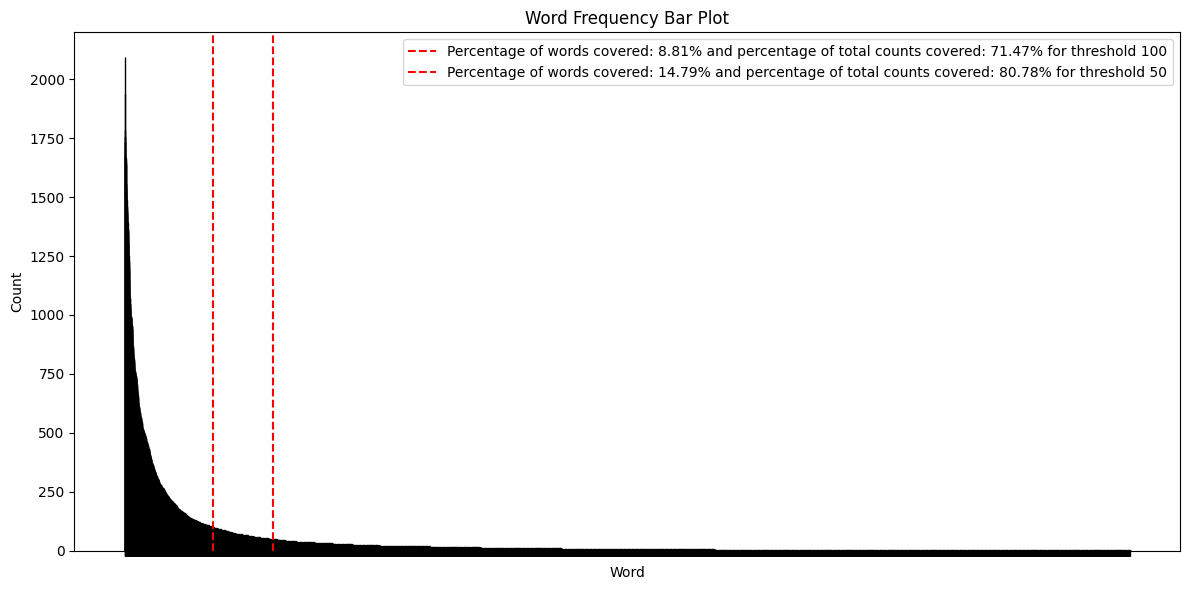

In [11]:
# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))

word_counter_sorted = word_counter
thresholds = [100, 50]  # Example thresholds

# Bar plot: Words on x-axis, counts on y-axis
ax.bar(
    word_counter_sorted['word'],
    word_counter_sorted['count'],
    color='skyblue',
    edgecolor='black'
)

# Title and axis labels (use ax.set_*, not ax.*)
ax.set_title('Word Frequency Bar Plot')
ax.set_xlabel('Word')
ax.set_ylabel('Count')
ax.set_xticklabels([])

# Rotate x-tick labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Draw a vertical line at the 10th bar (adjust as needed)

positions = [
    word_counter_sorted[word_counter_sorted['count'] < y].index[0] for y in thresholds
]

for xpos, yval in zip(positions, thresholds):
    all_words_len = word_counter_sorted['count'].sum()
    covered_words_len = word_counter_sorted['count'][:xpos].sum()
    percentage_words_covered = (covered_words_len/all_words_len)*100
    ax.axvline(
        x=xpos - 0.5,
        color='red',
        linestyle='--',
        label=f'Percentage of words covered: {(xpos/len(word_counter_sorted))*100:.2f}% and percentage of total counts covered: {percentage_words_covered:.2f}% for threshold {yval}'
    )

# Show legend
ax.legend()


# Adjust layout to fit labels
fig.tight_layout()
plt.show()


# Frequent Itemsets

In [12]:
# -- SENTENCES : list of lists of unique items --
# I will be talking about items as words from now on and transactions as sentences.
# -- SENTENCES : dict of sentence_id -> list of unique items --
sentences = {row['ID']: list(dict.fromkeys(row['token'])) 
             for _, row in data.iterrows()}
num_sentences = len(sentences)
print("Total number of sentences:", num_sentences)

# Flatten the values (sentence lists) to get all words
unique_items = set()
for sentence_items in sentences.values():
    unique_items.update(sentence_items)

# Create mapping from word to unique integer
word_to_id = {word: idx for idx, word in enumerate(sorted(unique_items))}

# Encode sentences using this dictionary (dict of sentence_id -> encoded list)
encoded_sentences = {sid: [word_to_id[word] for word in sentence] 
                   for sid, sentence in sentences.items()}
print("Encoded sentences sample:", dict(list(encoded_sentences.items())[-1:]))

Total number of sentences: 17567
Encoded sentences sample: {21593: [6504, 143, 9639, 4465, 5255, 1042, 3241, 8635, 10569, 9576, 1046, 2816, 4862, 3286, 9641, 3346, 2469, 5944, 10430, 9470, 2038, 7271, 6435, 7853, 4692, 7044, 6147, 1459, 8645, 6490, 6456, 3503]}


In [14]:
from itertools import combinations

def all_subsets_frequent(candidate, prev_frequent):
    """
    candidate: tuple, e.g. (2, 3, 4)
    prev_frequent: dict-like, keys are frequent (k-1)-itemsets as tuples
    """
    k = len(candidate)
    # generate all (k-1)-subsets of the candidate
    for subset in combinations(candidate, k - 1):
        print(subset)
        if subset not in prev_frequent:
            return False
    return True

In [17]:
# ----- SETUP -----
min_support = 0.01
all_words = [word for sentence in encoded_sentences.values() for word in sentence]  # Add .values()
num_sentences = len(encoded_sentences)

# ----- SINGLETON -----
singleton_counts = Counter(all_words)
print("Singleton counts:", singleton_counts)
singleton_counts_sup = {}

for word, count in singleton_counts.items():
    support = count / num_sentences
    if support >= min_support:
        singleton_counts_sup[(word,)] = round(support, 4)  # note the (word,)

# ----- OTHER K_VALUES -----
frequent_itemsets = {}
frequent_itemsets[1] = singleton_counts_sup

for k in range(2, len(unique_items) + 1):
    if len(frequent_itemsets[k - 1]) == 0:
        break  # No more frequent itemsets can be found

    print(f"Finding frequent itemsets of size {k}...")
    k_itemset_counts = Counter()

    prev_frequent = frequent_itemsets[k - 1]      # dict: keys = (k-1)-itemsets
    print(f"Previous frequent itemsets (k={k-1}): {prev_frequent}")
    prev_keys = sorted(
    [tuple(sorted([key])) if not isinstance(key, tuple) else tuple(sorted(key))
     for key in prev_frequent.keys()]
)
    candidates_k = set()

    for i in range(len(prev_keys)):
        for j in range(i + 1, len(prev_keys)):
            a = prev_keys[i]
            b = prev_keys[j]

            if k == 2:
                # generate all size-2 pairs from singletons
                if a != b:
                    candidate = tuple(sorted(set(a) | set(b)))
                    candidates_k.add(candidate)
            else:
                # Apriori join: first k-2 items must match (on sorted tuples)
                if a[:-1] == b[:-1]:
                    candidate = tuple(sorted(set(a) | set(b)))
                    if (len(candidate) == k and
                        all_subsets_frequent(candidate, prev_frequent)):
                        candidates_k.add(candidate)

    # Count occurrences of each candidate in the sentences
    for sentence in encoded_sentences.values():  # Add .values() here
        s = set(sentence)
        for candidate in candidates_k:
            if set(candidate).issubset(s):
                k_itemset_counts[candidate] += 1

    # Filter candidates by min_support
    k_itemset_counts_sup = {}
    for candidate, count in k_itemset_counts.items():
        support = count / num_sentences
        if support >= min_support:
            k_itemset_counts_sup[candidate] = round(support, 4)

    frequent_itemsets[k] = k_itemset_counts_sup


Singleton counts: Counter({10789: 1711, 3346: 1689, 3274: 1652, 8077: 1643, 2235: 1595, 4101: 1588, 4209: 1556, 475: 1546, 3601: 1542, 9777: 1540, 5944: 1521, 5310: 1491, 4458: 1489, 4146: 1465, 1730: 1458, 9617: 1441, 6277: 1438, 7806: 1429, 6861: 1416, 4755: 1389, 571: 1375, 10530: 1373, 929: 1369, 10594: 1360, 6084: 1359, 5255: 1340, 5508: 1332, 5551: 1328, 7591: 1302, 9684: 1300, 5450: 1285, 9629: 1284, 4367: 1252, 370: 1246, 10738: 1246, 6645: 1233, 938: 1220, 2816: 1218, 9638: 1200, 8588: 1193, 10569: 1160, 6411: 1154, 6837: 1152, 6456: 1139, 3241: 1106, 8357: 1097, 1440: 1075, 1042: 1058, 894: 1048, 10571: 1031, 10246: 1007, 339: 999, 872: 997, 8675: 989, 3136: 989, 616: 978, 3603: 972, 2774: 971, 8440: 969, 1088: 967, 4409: 965, 9341: 962, 7097: 960, 4085: 960, 6725: 955, 9652: 951, 6570: 941, 7487: 940, 758: 938, 7445: 933, 39: 925, 5629: 914, 9612: 900, 10561: 898, 6211: 891, 5278: 882, 5604: 881, 4973: 876, 858: 869, 10790: 859, 5719: 848, 1355: 838, 8364: 838, 6504: 828, 65

In [18]:
rows = []

for k, itemsets_dict in frequent_itemsets.items():
    for fs, supp in itemsets_dict.items():
        rows.append({
            'k': k,
            'itemset': tuple(fs),
            'support': supp
        })

df = pd.DataFrame(rows)
df.to_csv('frequent_itemsets_all_k_2.csv', index=False)

In [27]:
df.to_csv('../pre_results/frequent_itemsets/frequent_itemsets_all_k.csv', index=False)

# Analysis Itemsets results

## Confidence

In [19]:
confidence_dict = {}
for k in range(2, len(frequent_itemsets)):
    print(f"Calculating confidence for itemsets of size {k}...")
    for itemset in frequent_itemsets[k].keys():
        itemset_support = frequent_itemsets[k][itemset]
        #print(f"Itemset: {itemset}, Size of Itemset: {len(itemset)}, Support: {itemset_support}")
        for i in range(len(itemset)):
            antecedent = itemset[:i] + itemset[i+1:]
            #print(f"  Antecedent: {antecedent}")
            consequent = (itemset[i],)
            #print(f"  Consequent: {consequent}")
            antecedent_support = frequent_itemsets[len(antecedent)].get(antecedent, 0)
            #print(f"  Antecedent Support: {antecedent_support}")
            if antecedent_support > 0:
                confidence = itemset_support / antecedent_support
                confidence_dict[(antecedent, consequent)] = round(confidence, 4)

Calculating confidence for itemsets of size 2...
Calculating confidence for itemsets of size 3...


In [20]:
association_rules_df = pd.DataFrame([
    {'Antecedent': antecedent, 'Consequent': consequent, 'Confidence': confidence}
    for (antecedent, consequent), confidence in confidence_dict.items()
])

id_to_word = {v: k for k, v in word_to_id.items()}

def ids_to_words(t):
    return tuple(id_to_word[i] for i in t)

association_rules_df["Antecedent Word"] = association_rules_df["Antecedent"].apply(ids_to_words)
association_rules_df["Consequent Word"] = association_rules_df["Consequent"].apply(ids_to_words)
association_rules_df = association_rules_df.sort_values(by='Confidence', ascending=False)
association_rules_df.head(20)

,Antecedent,Consequent,Confidence,Antecedent Word,Consequent Word
210,"(6725, 7346)","(2235,)",1.0000,"(partner, prospective)","(current,)"
122,"(7346,)","(2235,)",0.9949,"(prospective,)","(current,)"
211,"(2235, 7346)","(6725,)",0.9796,"(current, prospective)","(partner,)"
120,"(7346,)","(6725,)",0.9746,"(prospective,)","(partner,)"
155,"(2877,)","(10469,)",0.9191,"(drinking,)","(water,)"
187,"(2876,)","(10469,)",0.7969,"(drink,)","(water,)"
36,"(8742,)","(2816,)",0.7669,"(slow,)","(down,)"
64,"(6776,)","(684,)",0.7534,"(pay,)","(attention,)"
212,"(2235, 6725)","(7346,)",0.7356,"(current, partner)","(prospective,)"
160,"(7754,)","(3346,)",0.7152,"(regimen,)","(exercise,)"


## Lift

In [21]:
def get_consequent_support(consequent):
    return frequent_itemsets[1].get(consequent, 0)

association_rules_df["Support_consequent"] = association_rules_df["Consequent"].apply(
    get_consequent_support
)

association_rules_df["Lift"] = (
    association_rules_df["Confidence"] / association_rules_df["Support_consequent"]
)

## Interest

In [22]:
association_rules_df["Support_consequent"] = association_rules_df["Consequent"].apply(
    get_consequent_support
)

association_rules_df["Interest"] = (
    association_rules_df["Confidence"] - association_rules_df["Support_consequent"]
)

## Final Metrics

In [23]:
association_rules_df

,Antecedent,Consequent,Confidence,Antecedent Word,Consequent Word,Support_consequent,Lift,Interest
210,"(6725, 7346)","(2235,)",1.0000,"(partner, prospective)","(current,)",0.0908,11.013216,0.9092
122,"(7346,)","(2235,)",0.9949,"(prospective,)","(current,)",0.0908,10.957048,0.9041
211,"(2235, 7346)","(6725,)",0.9796,"(current, prospective)","(partner,)",0.0544,18.007353,0.9252
120,"(7346,)","(6725,)",0.9746,"(prospective,)","(partner,)",0.0544,17.915441,0.9202
155,"(2877,)","(10469,)",0.9191,"(drinking,)","(water,)",0.0428,21.474299,0.8763
...,...,...,...,...,...,...,...,...
195,"(3346,)","(6084,)",0.1082,"(exercise,)","(most,)",0.0774,1.397933,0.0308
14,"(10789,)","(10594,)",0.1068,"(you're,)","(who,)",0.0774,1.379845,0.0294
197,"(3346,)","(10571,)",0.1061,"(exercise,)","(while,)",0.0587,1.807496,0.0474
206,"(3346,)","(339,)",0.1061,"(exercise,)","(alignment,)",0.0569,1.864675,0.0492


If Lift(I → j) is close to 1, then the rule is “not really interesting”.

If Lift(I → j) is much greater than 1, then the presence of I encourages the purchase of j.

If Lift(I → j) is much less than 1, then the presence of I discourages the purchase of j.

------

If Interest(I → j) is close to 0, then the rule is not really interesting.

If Interest(I → j) is highly positive, then I encourages buying j.

If Interest(I → j) is highly negative, then I discourages buying j.

In [24]:
order_by = "Interest"

association_rules_df = association_rules_df.sort_values(by=order_by, ascending=False)
association_rules_df

,Antecedent,Consequent,Confidence,Antecedent Word,Consequent Word,Support_consequent,Lift,Interest
211,"(2235, 7346)","(6725,)",0.9796,"(current, prospective)","(partner,)",0.0544,18.007353,0.9252
120,"(7346,)","(6725,)",0.9746,"(prospective,)","(partner,)",0.0544,17.915441,0.9202
210,"(6725, 7346)","(2235,)",1.0000,"(partner, prospective)","(current,)",0.0908,11.013216,0.9092
122,"(7346,)","(2235,)",0.9949,"(prospective,)","(current,)",0.0908,10.957048,0.9041
155,"(2877,)","(10469,)",0.9191,"(drinking,)","(water,)",0.0428,21.474299,0.8763
...,...,...,...,...,...,...,...,...
62,"(10789,)","(1730,)",0.1047,"(you're,)","(come,)",0.0830,1.261446,0.0217
95,"(2235,)","(3274,)",0.1156,"(current,)","(even,)",0.0940,1.229787,0.0216
94,"(3274,)","(2235,)",0.1117,"(even,)","(current,)",0.0908,1.230176,0.0209
19,"(3274,)","(10789,)",0.1149,"(even,)","(you're,)",0.0974,1.179671,0.0175
